# Improved.ipynb

Experimenting with different PCA dimensions...
n_components = 1: Mean Accuracy = 0.8866
n_components = 2: Mean Accuracy = 0.8994
n_components = 3: Mean Accuracy = 0.9112
n_components = 4: Mean Accuracy = 0.9081
n_components = 5: Mean Accuracy = 0.9114
n_components = 6: Mean Accuracy = 0.9118


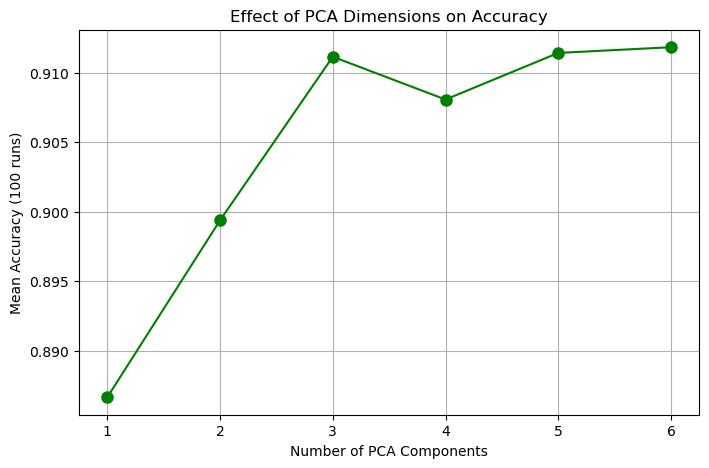


Optimal number of components is: 6


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

df = pd.read_csv('Wholesale customers data.csv')
y = df['Channel']
X_raw = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]

X_log_scaled = StandardScaler().fit_transform(np.log1p(X_raw))

components_range = range(1, 7)
results = []

best_k = 10 

print("Experimenting with different PCA dimensions...")

for n in components_range:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_log_scaled)
    
    scores = []
    for i in range(100):
        X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.33, random_state=i)
        knn = KNeighborsClassifier(n_neighbors=best_k)
        knn.fit(X_train, y_train)
        scores.append(accuracy_score(y_test, knn.predict(X_test)))
    
    mean_acc = np.mean(scores)
    results.append(mean_acc)
    print(f"n_components = {n}: Mean Accuracy = {mean_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(components_range, results, 'o-', color='green', markersize=8)
plt.title('Effect of PCA Dimensions on Accuracy')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Accuracy (100 runs)')
plt.xticks(components_range)
plt.grid(True)
plt.show()

optimal_n = components_range[np.argmax(results)]
print(f"\nOptimal number of components is: {optimal_n}")

In [2]:
df = pd.read_csv('Wholesale customers data.csv')
y = df['Channel']
X_raw = df.drop(['Channel', 'Region'], axis=1)

scaler = StandardScaler()
X_base = scaler.fit_transform(X_raw)

X_log = np.log1p(X_raw)

X_log_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=3)
X_imp = pca.fit_transform(X_log_scaled)

print(f"Baseline features: {X_base.shape[1]}")
print(f"Improved features (after PCA): {X_imp.shape[1]}")

Baseline features: 6
Improved features (after PCA): 3


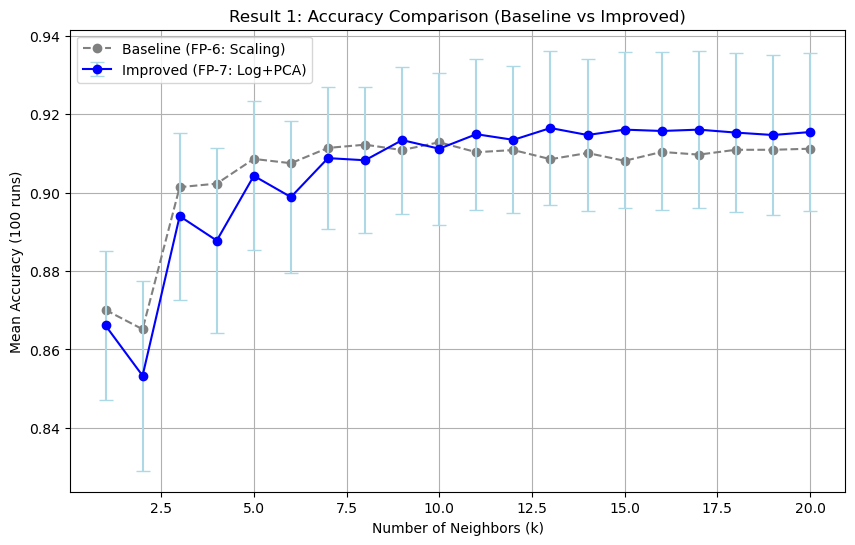

Best K for Improved Model: 13
Peak Accuracy - Baseline: 0.913
Peak Accuracy - Improved: 0.916


In [3]:
k_values = range(1, 21)
acc_base_mean = []
acc_imp_mean = []
acc_imp_std = [] 

for k in k_values:
    base_scores = []
    imp_scores = []
    for i in range(100):
        X_tr_b, X_te_b, y_tr, y_te = train_test_split(X_base, y, test_size=0.33, random_state=i)
        X_tr_i, X_te_i, _, _ = train_test_split(X_imp, y, test_size=0.33, random_state=i)
        
        knn_base = KNeighborsClassifier(n_neighbors=k)
        knn_base.fit(X_tr_b, y_tr)
        base_scores.append(accuracy_score(y_te, knn_base.predict(X_te_b)))
        
        knn_imp = KNeighborsClassifier(n_neighbors=k)
        knn_imp.fit(X_tr_i, y_tr)
        imp_scores.append(accuracy_score(y_te, knn_imp.predict(X_te_i)))
    
    acc_base_mean.append(np.mean(base_scores))
    acc_imp_mean.append(np.mean(imp_scores))
    acc_imp_std.append(np.std(imp_scores))

plt.figure(figsize=(10, 6))
plt.plot(k_values, acc_base_mean, 'o--', color='gray', label='Baseline (FP-6: Scaling)')
plt.errorbar(k_values, acc_imp_mean, yerr=acc_imp_std, fmt='-o', color='blue', ecolor='lightblue', capsize=5, label='Improved (FP-7: Log+PCA)')

plt.title('Result 1: Accuracy Comparison (Baseline vs Improved)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy (100 runs)')
plt.legend()
plt.grid(True)
plt.show()

best_k_idx = np.argmax(acc_imp_mean)
best_k = k_values[best_k_idx]
print(f"Best K for Improved Model: {best_k}")
print(f"Peak Accuracy - Baseline: {max(acc_base_mean):.3f}")
print(f"Peak Accuracy - Improved: {max(acc_imp_mean):.3f}")

C:\Users\youza\AppData\Local\Temp\ipykernel_25676\1581139625.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


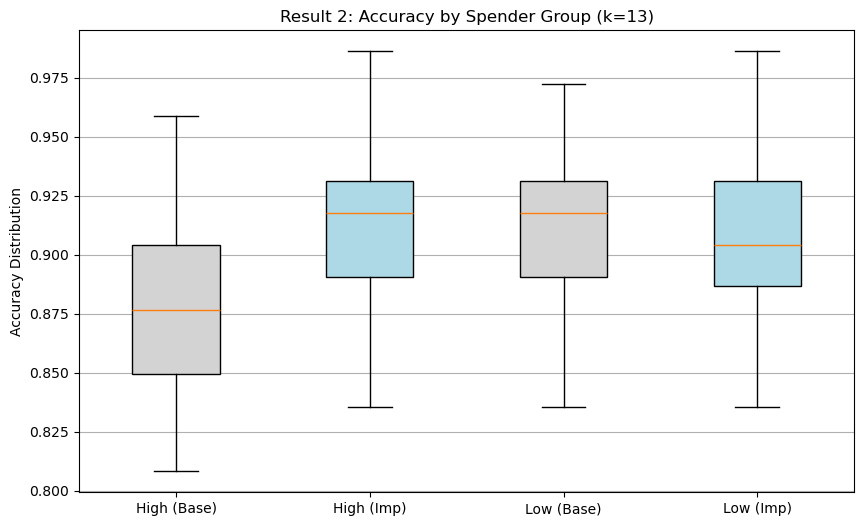

In [4]:
total_spend = X_raw.sum(axis=1)
median_spend = total_spend.median()
mask_high = total_spend > median_spend
mask_low = total_spend <= median_spend

def get_subset_scores(X_data, y_data, mask, k):
    X_sub = X_data[mask]
    y_sub = y_data[mask]
    scores = []
    for i in range(100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.33, random_state=i)
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_te, knn.predict(X_te)))
    return scores

scores_base_high = get_subset_scores(X_base, y, mask_high, best_k)
scores_imp_high = get_subset_scores(X_imp, y, mask_high, best_k)
scores_base_low = get_subset_scores(X_base, y, mask_low, best_k)
scores_imp_low = get_subset_scores(X_imp, y, mask_low, best_k)

data_to_plot = [scores_base_high, scores_imp_high, scores_base_low, scores_imp_low]
labels = ['High (Base)', 'High (Imp)', 'Low (Base)', 'Low (Imp)']
colors = ['lightgray', 'lightblue', 'lightgray', 'lightblue']

plt.figure(figsize=(10, 6))
bplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title(f'Result 2: Accuracy by Spender Group (k={best_k})')
plt.ylabel('Accuracy Distribution')
plt.grid(True, axis='y')
plt.show()